In [1]:
from tensorboard.backend.event_processing import event_accumulator

from pathlib import Path

from glob import glob

import pandas as pd 

from matplotlib import pyplot as plt

from xaikd import models, datasets
from xaikd.utils import metrics

import numpy as np 

In [2]:
DATASET = "cifar100-people"

In [3]:
ACCURACY_CACHE = dict()

def get_accuracy(arch, dataset):
    
    
    key = f"{arch}-{dataset}"

    if key in ACCURACY_CACHE:
        return ACCURACY_CACHE[key]
    
    
    model = models.get_model(arch)
    ds = datasets.construct(dataset)
    
    val_dl = ds.loader(train_split=False)
    
    acc = metrics.accuracy_with_subclasses(
        model, 
        val_dl,
        ds.selected_classes,
        ds.transform_target,
        device="cpu"
    )
    
    ACCURACY_CACHE[key] = acc
    
    return get_accuracy(arch, dataset)
    
teacher_acc = get_accuracy("cifar100-resnet18-p1", DATASET)
teacher_acc

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


0.550000011920929

In [7]:
BASELINE_DATA_DIR = Path("../../artifacts/2023-07-s9/experiments/baselines-with-mse")

def get_baseline(layer, mode, nsamples, col, lambda_mse, lambda_xent):
    
    seeds = list(range(1, 5+1))[:1]

    rows = []
    for seed in seeds:
        path = BASELINE_DATA_DIR / f"{DATASET}-seed{seed}" / f"cifar100-resnet18-p1--layer-{layer}--mode-{mode}--n{nsamples}-lmse{lambda_mse}-lxent{lambda_xent}/lightning_logs/version_0/*.tfevents*"
        files = glob(f"{path}")
        if len(files) == 0 and mode[-1] == "0":
            # sometimes, we have compr0.2 saved but we retrieve via compr0.20
            return get_baseline(layer, mode[:-1], nsamples, col, lambda_mse, lambda_xent)

        tfevent = files[0]
        ea = event_accumulator.EventAccumulator(tfevent)
        ea.Reload()

        for r in ea.Scalars(col):
            rows.append(dict(step=r.step, seed=seed, col=r.value))

    df =  pd.DataFrame(rows)
    return df.groupby("step").agg({'step': ['max'], "col": ['mean', 'std', 'count']})
    
    
    
__df = get_baseline("layer3", mode="homogenous-compr0.10", nsamples=50, col="val_acc", lambda_mse=1.0, lambda_xent=1.0)
__df

step    col          
      max   mean std count
step                      
0       0  0.166 NaN     1
1       1  0.214 NaN     1
2       2  0.222 NaN     1
3       3  0.232 NaN     1
4       4  0.222 NaN     1
...   ...    ...  ..   ...
95     95  0.414 NaN     1
96     96  0.436 NaN     1
97     97  0.436 NaN     1
98     98  0.452 NaN     1
99     99  0.430 NaN     1

[100 rows x 4 columns]

In [9]:
BASIS_DATA_DIR = Path("../../artifacts/2023-07-s9/experiments/distillation-with-mse-fixed-eval")

def get_basis_performance(layer, basis_name, compr_rate, nsamples, col, lambda_mse, lambda_xent):
    
    nseeds = list(range(1, 5+1))[:1]
    rows = []

    for seed in nseeds:

        path = BASIS_DATA_DIR \
            / f"{DATASET}/cifar100-resnet18-p1/layer{layer}-n{nsamples}-wd0.0-ldmse{lambda_mse}-ldxent{lambda_xent}-comp{compr_rate}-seed{seed}" \
            / basis_name \
            / "log/*/version_0/*.tfevents*"

        tfevent = glob(f"{path}")[0]

        ea = event_accumulator.EventAccumulator(tfevent)

        ea.Reload()


        for r in ea.Scalars(col):
            rows.append(dict(step=r.step, col=r.value))
    df =  pd.DataFrame(rows)
    return df.groupby("step").agg({'step': ['max'], "col": ['mean', 'std', 'count']})
    
#     return pd.DataFrame(rows)
    
get_basis_performance(
    "layer3", basis_name="prca-recon--centered", compr_rate=0.10, nsamples=50, col="val_acc", lambda_mse=1.0, lambda_xent=1.0)

step    col          
      max   mean std count
step                      
0       0  0.216 NaN     1
1       1  0.220 NaN     1
2       2  0.244 NaN     1
3       3  0.242 NaN     1
4       4  0.238 NaN     1
...   ...    ...  ..   ...
95     95  0.430 NaN     1
96     96  0.432 NaN     1
97     97  0.430 NaN     1
98     98  0.432 NaN     1
99     99  0.432 NaN     1

[100 rows x 4 columns]

In [9]:
def marker(basis_name):
    if basis_name in ["prca-abs--centered", "prca-recon--centered"]:
        return "|"
    if "pcaprca" in basis_name:
        return "."
#     elif "prca-recon" in basis_name:
#         return "."
    else:
        return ""
    
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    else:
        return "-"
def viz(
    compr_rate, col, nsamples,
    skip_baseline=False,
    arr_lambda_mse_xent_pairs = [
        (1.0, 1.0),
        (0.0, 1.0),
        (1.0, 0.0),
    ],
    basis_names = [
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs",
        "pcaprca-abs",
        "random1"
    ]
):
    layer = "layer3"
    nrows = 1 
    

    ncols = len(arr_lambda_mse_xent_pairs)
    
    plt.figure(figsize=(5*ncols*1.5, 3*nrows*1.5))
    
    
    
    for nix, (lambda_mse, lambda_xent) in enumerate(arr_lambda_mse_xent_pairs):
        plt.subplot(1, ncols, nix+1)
    

        plt.ylabel(col)
        plt.axhline(teacher_acc, label=f"Teacher Acc(val)={teacher_acc:.4f}", ls="--", lw=1, color='k')

        for mode in ["homogenous", f"homogenous-compr{compr_rate:.2f}"]:
            print(f"baseline={mode}")
            if skip_baseline:
                break
            df = get_baseline(layer, mode=mode, nsamples=nsamples, col=col, lambda_mse=lambda_mse, lambda_xent=lambda_xent)

            mean = df.col[["mean"]].values.reshape(-1)
            nseeds = df.col[["count"]].values.reshape(-1)[0]
            stderr = df.col[["std"]].values.reshape(-1) / (nseeds**0.5)
            steps = df.step[["max"]].values.reshape(-1)
            steps = np.arange(steps.shape[0])
            label = f"{mode}(max={mean.max():.4f})"


            plt.plot(
                steps,
                mean,
                label=label,
                ls='--'
            )

            plt.fill_between(
                steps,
                mean - stderr,
                mean + stderr,
                alpha=0.1
            )

        for basis_name in basis_names:
            basis_name = f"{basis_name}--centered"
            df = get_basis_performance(
                layer, basis_name=basis_name, compr_rate=compr_rate, nsamples=nsamples, col=col,
                lambda_mse=lambda_mse,
                lambda_xent=lambda_xent
            )

            mean = df.col[["mean"]].values.reshape(-1)
            nseeds = df.col[["count"]].values.reshape(-1)[0]
            stderr = df.col[["std"]].values.reshape(-1) / (nseeds**0.5)
            
            steps = df.step[["max"]].values.reshape(-1)
            steps = np.arange(steps.shape[0])

            label = f"{basis_name}(max={mean.max():.4f})"
            
            if "pcaprca" in basis_name:
                color = plt.gca().lines[-1].get_color()
            else:
                color=None
            plt.plot(
                steps,
                mean,
                label=label,
                ls=ls(basis_name),
                marker=marker(basis_name),
                color=color
            )
            
            plt.fill_between(
                steps,
                mean - stderr,
                mean + stderr,
                alpha=0.1
            )

        plt.title(f"lambda_mse={lambda_mse},lambda_xent={lambda_xent}")

        plt.legend()

        plt.xlabel("Epoch")
        plt.ylim([0.18, teacher_acc+0.05])
        plt.axhline(0.20, ls=":", alpha=0.5, color="k")
    plt.suptitle(f"{DATASET}: layer={layer}, nsamples={nsamples}, compr_rate={compr_rate}, nseeds={nseeds}")        

baseline=homogenous
baseline=homogenous-compr0.10


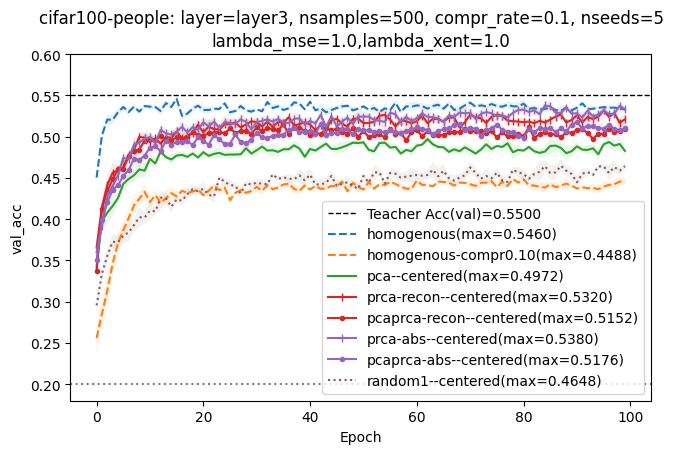

In [12]:
BASELINE_DATA_DIR = Path("../../artifacts/2023-07-s9/dev/baseline-scaling-w-seeds")
BASIS_DATA_DIR = Path("../../artifacts/2023-07-s9/dev/distill-fix-decoder")

viz(
    nsamples=500,
    compr_rate=0.10,
    col="val_acc",
    skip_baseline=False,
    arr_lambda_mse_xent_pairs=[(1.0, 1.0)],
    basis_names=[
            "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs",
        "pcaprca-abs",
        "random1"
    ]
)


# Influence of MSE and XENT

baseline=homogenous
baseline=homogenous-compr0.05
baseline=homogenous
baseline=homogenous-compr0.05
baseline=homogenous
baseline=homogenous-compr0.05
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.25
baseline=homogenous
baseline=homogenous-compr0.25
baseline=homogenous
baseline=homogenous-compr0.25


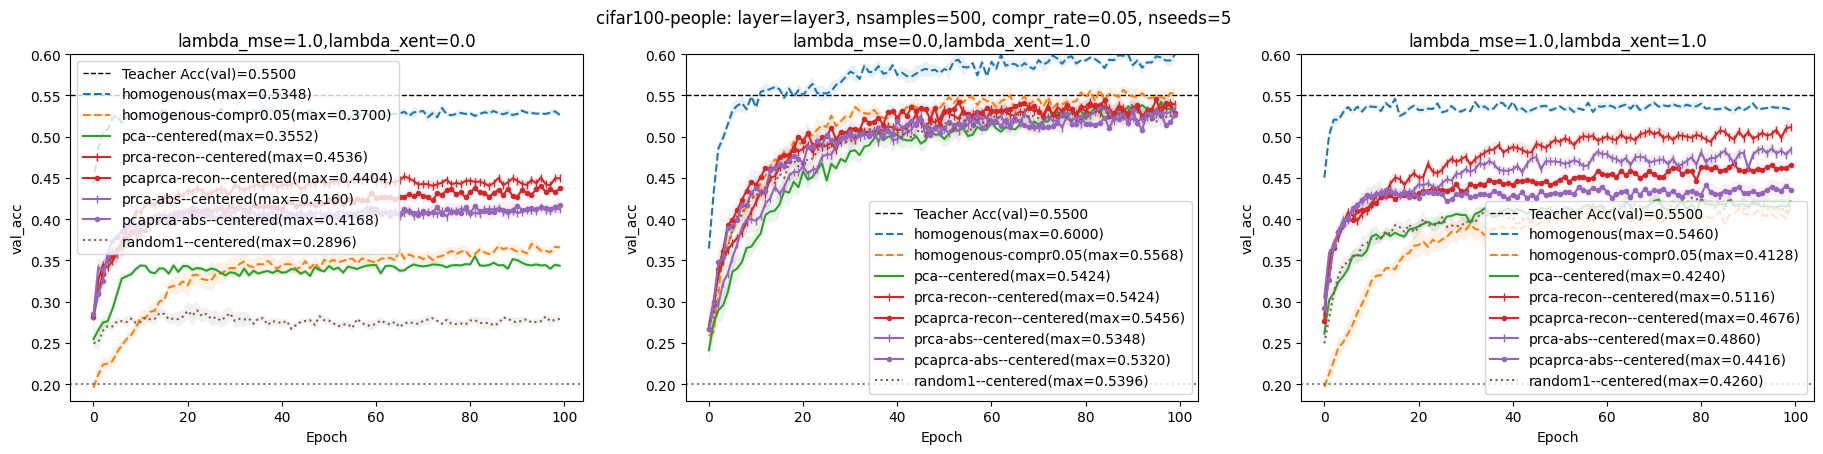

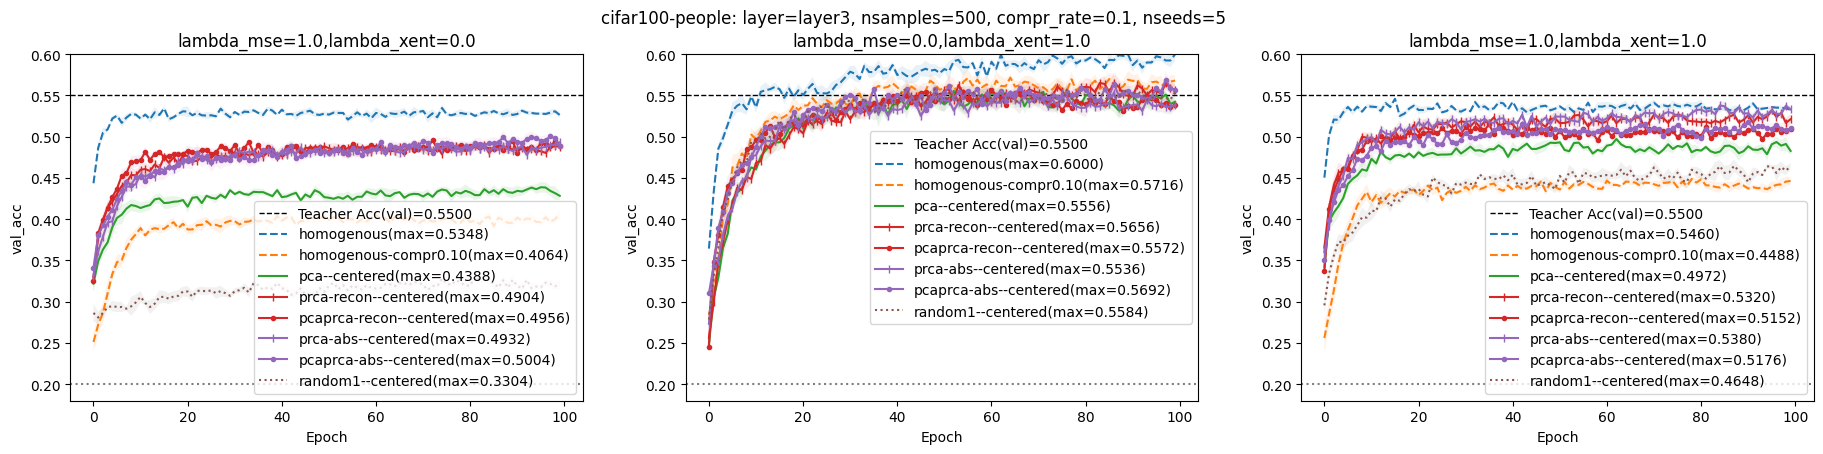

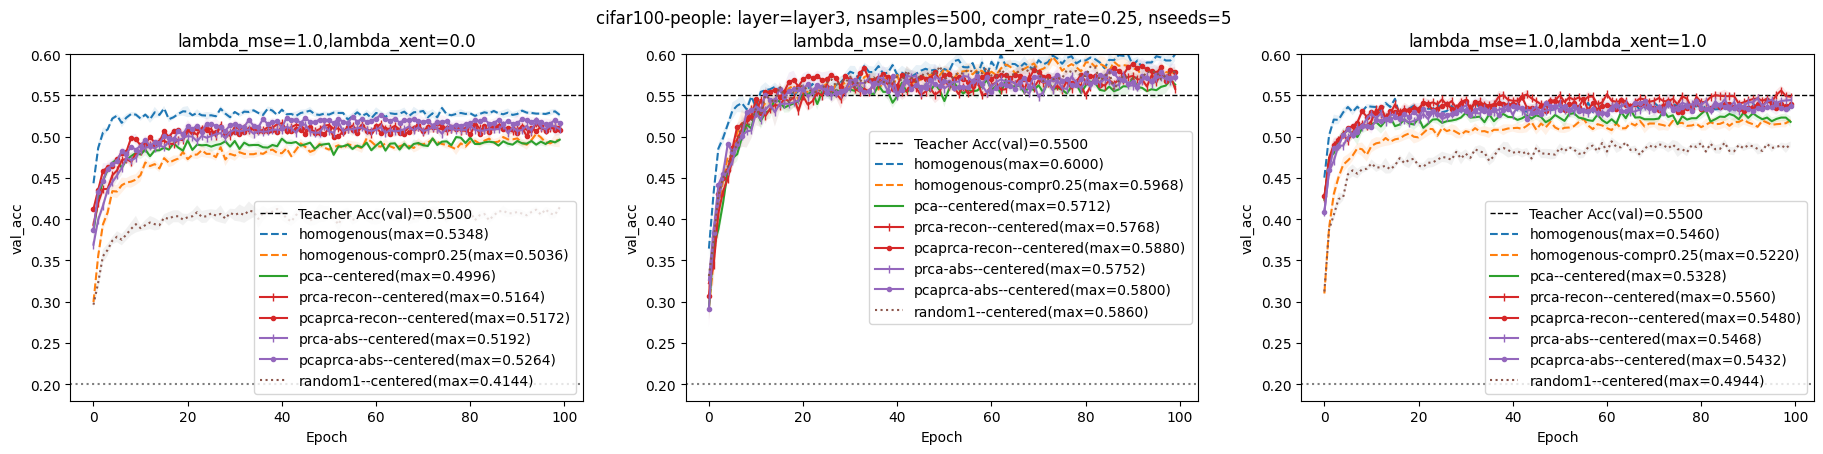

In [18]:
for compr_rate in [0.05, 0.1, 0.25]:
    viz(
        nsamples=500,
        compr_rate=compr_rate,
        col="val_acc",
        skip_baseline=False,
        arr_lambda_mse_xent_pairs=[
            (1.0, 0.0),
            (0.0, 1.0),
            (1.0, 1.0),
        ],
    basis_names=[
        "pca",
        "prca-recon",
        "pcaprca-recon",
        "prca-abs",
        "pcaprca-abs",
        "random1"
    ]
    )

# Influence of Training Samples

baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10
baseline=homogenous
baseline=homogenous-compr0.10


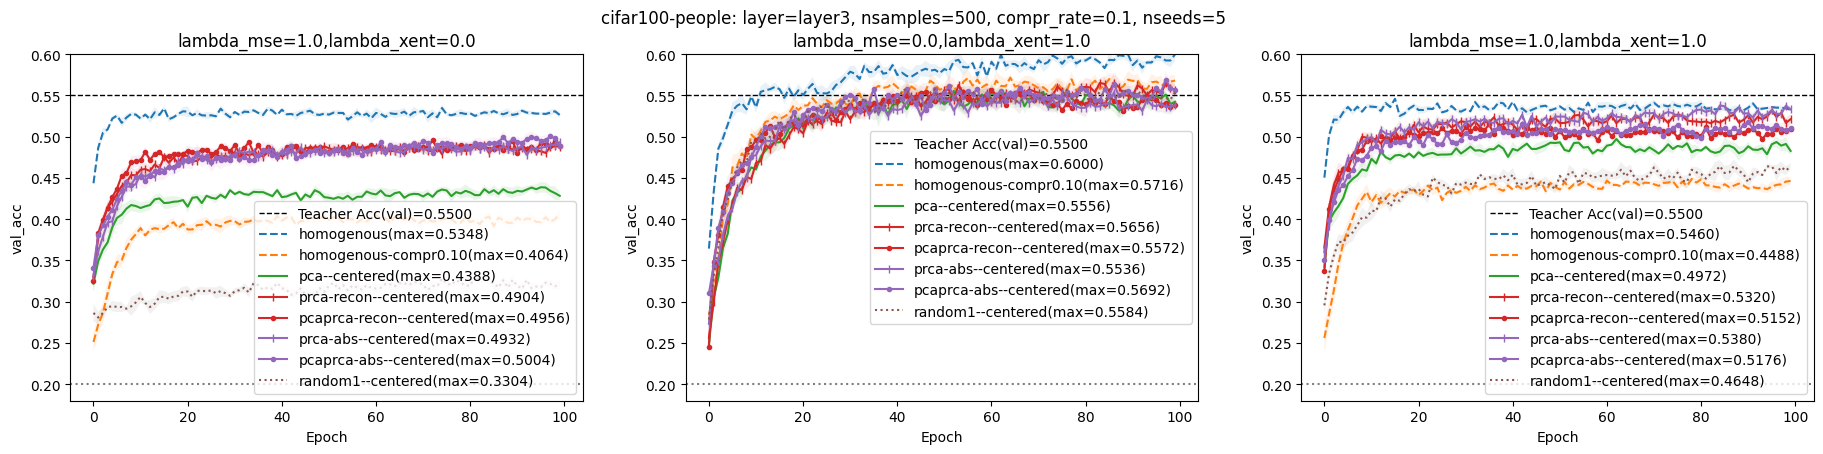

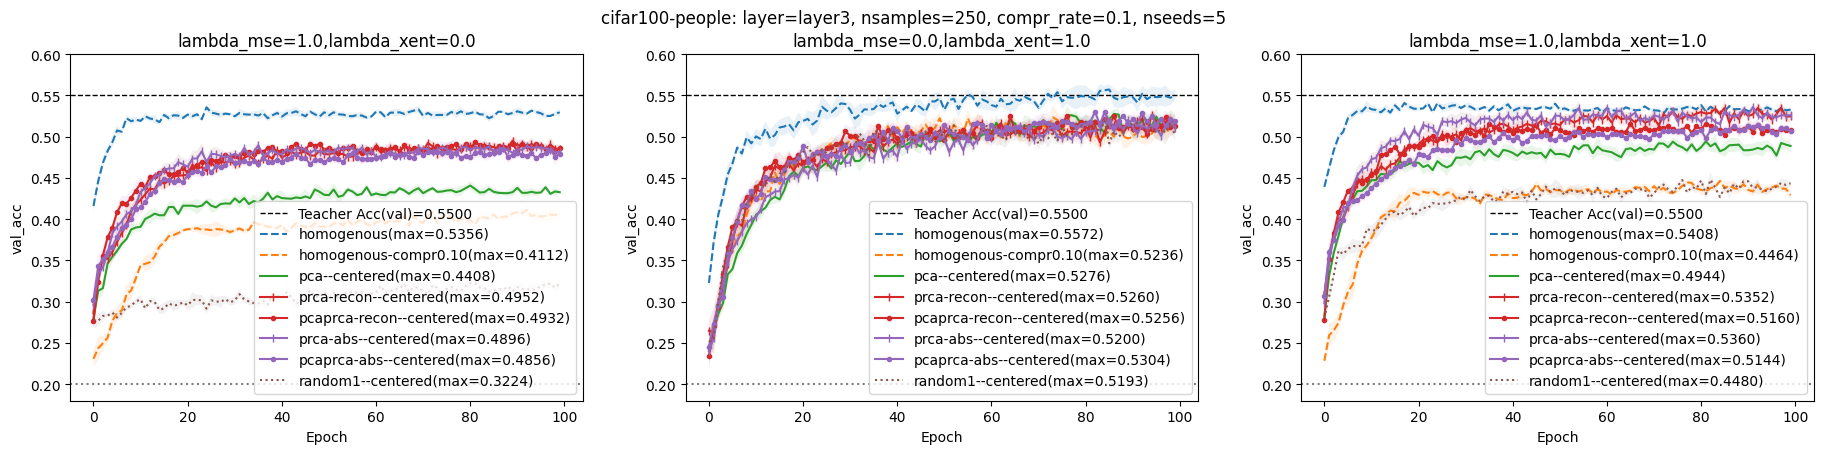

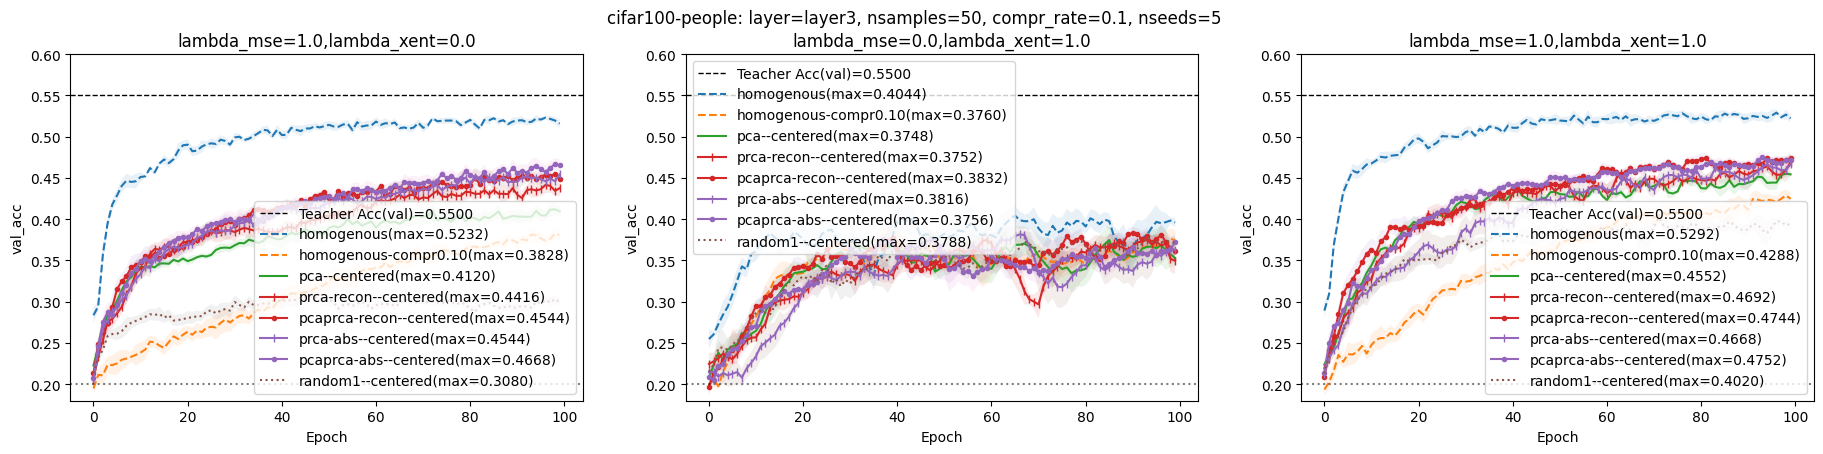

In [20]:
for nsamples in [500, 250, 50]:
    viz(
        nsamples=nsamples,
        compr_rate=0.1,
        col="val_acc",
        skip_baseline=False,
        arr_lambda_mse_xent_pairs=[
            (1.0, 0.0),
            (0.0, 1.0),
            (1.0, 1.0),
        ],
    )


baseline=homogenous
baseline=homogenous
baseline=homogenous
baseline=homogenous
baseline=homogenous
baseline=homogenous


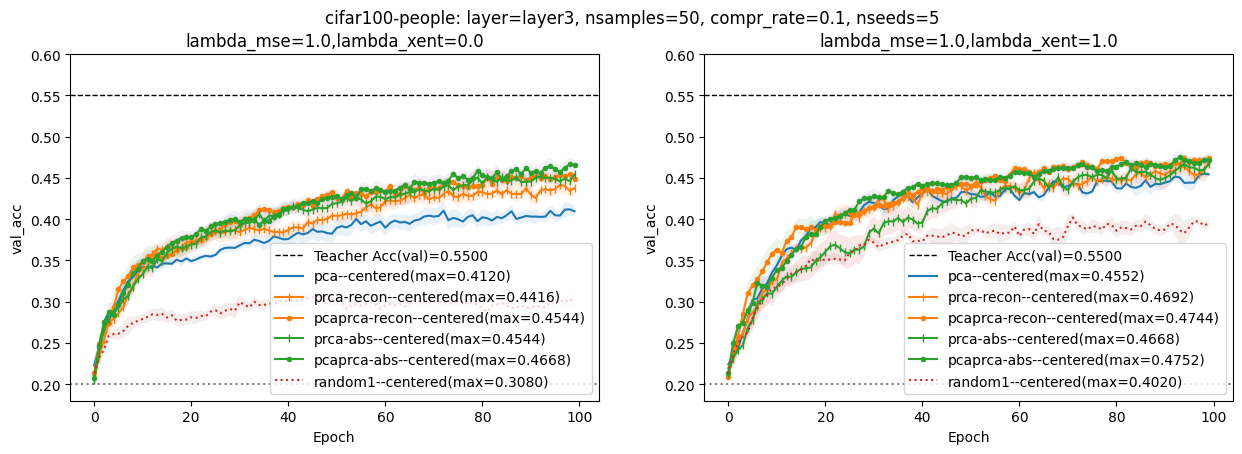

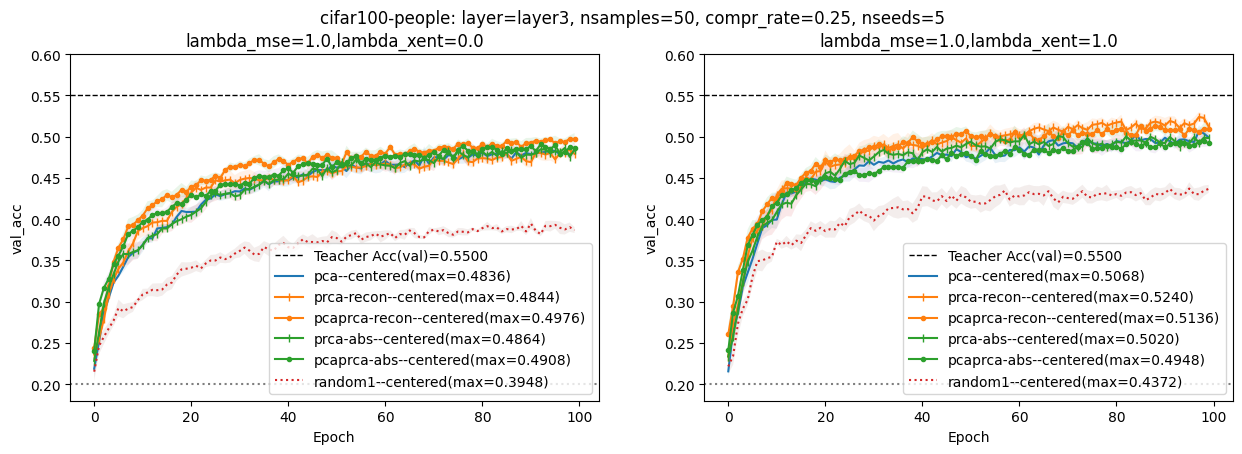

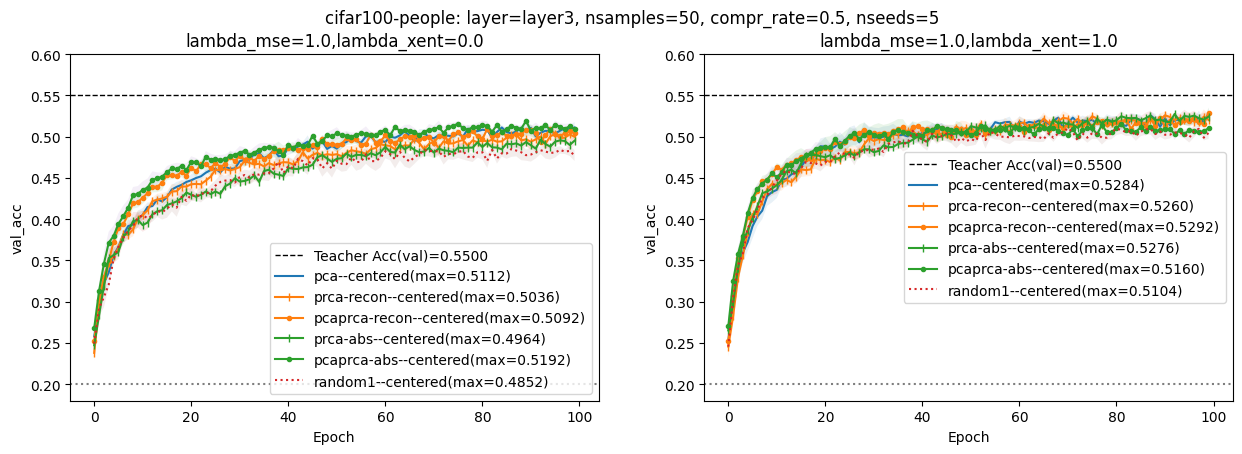

In [27]:
for compr_rate in [0.1, 0.25, 0.5]:
    viz(
        nsamples=50,
        compr_rate=compr_rate,
        col="val_acc",
        skip_baseline=True,
        arr_lambda_mse_xent_pairs=[
            (1.0, 0.0),
#             (0.0, 1.0),
            (1.0, 1.0),
        ],
    )
